# Import

In [1]:
import sys
from pathlib import Path

qml_code_dir = Path.cwd().parent
sys.path.append(str(qml_code_dir))

from sklearn.datasets import load_breast_cancer
from sklearn.datasets import make_circles
from sklearn.utils import Bunch

from moduli.preprocessing_dataset.preprocessing_dataset import preprocessa_dataset
from moduli.qsvm.qsvm import costruisci_qsvm
from moduli.kernel import kernel_amplitude
from moduli.kernel import kernel_angle
from moduli.kernel import kernel_basis
from moduli.kernel import kernel_IQP

import itertools

# Configurazione

In [2]:
# Numero di campioni da estrarre dal dataset totale.

numero_campioni = 200

# Rapporti con cui dividere il numero di campioni estratti fra il set per il training, quello per la validazione e quello per il test.

frazione_dati_per_train = 0.70
frazione_dati_per_val = 0.15
frazione_dati_per_test = 0.15

# Numero di features da utilizzare.

numero_features = 3

# Creazione o importazione dei dataset

In [3]:
# breast_cancer.

dataset_breast_cancer = load_breast_cancer()

# make_circles.

X_circles, y_circles = make_circles(n_samples = 5000, noise = 0.1, factor = 0.3, random_state = 1)
dataset_make_circles = Bunch(data = X_circles, target = y_circles) # serve per raccogliere i dati in maniera che preprocessing li legga, come breast cancer

# Preprocessing

In [4]:
dataset_scelto = dataset_breast_cancer

set_preparato = preprocessa_dataset(
    dataset_scelto = dataset_scelto,
    numero_campioni = numero_campioni,
    frazione_dati_per_train = frazione_dati_per_train,
    frazione_dati_per_val = frazione_dati_per_val,
    frazione_dati_per_test = frazione_dati_per_test,
    numero_features = numero_features
)


PREPROCESSING DATASET

Il numero di campioni da estrarre desiderato è valido.
I rapporti scelti sono validi.
Il numero di features richiesto, 3, è minore della quantità totale di features presenti nel dataset, 30.
PCA eseguita con successo. Informazione conservata: 73.89%
Preprocessing del dataset completato.



# Amplitude Encoding

## Iperparametri dell'encoding

In [5]:
# Iperparametri quantistici: None.

iperparametri_quantistici_amplitude = {}

# Iperparametri classici.

iperparametri_classici_amplitude = {"C": [1.0, 10.0, 100.0, 1000.0]} 

## QSVM

QUANTUM SUPPORT VECTOR MACHINE PER AMPLITUDE ENCODING

Destinazione output: risultati_run/20260629/20260629_111736/amplitude_encoding_20260629_111736


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 4/4


Miglior iperparametro classico per C: 10.0
F1-Score (Macro) del miglior modello sul validation set: 57.39%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   66.67%    │  18.18%  │   28.57%   │              11               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   66.67%    │  94.74%  │   78.26%   │              19               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   66.67%    │  56.46%  │   53.42%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


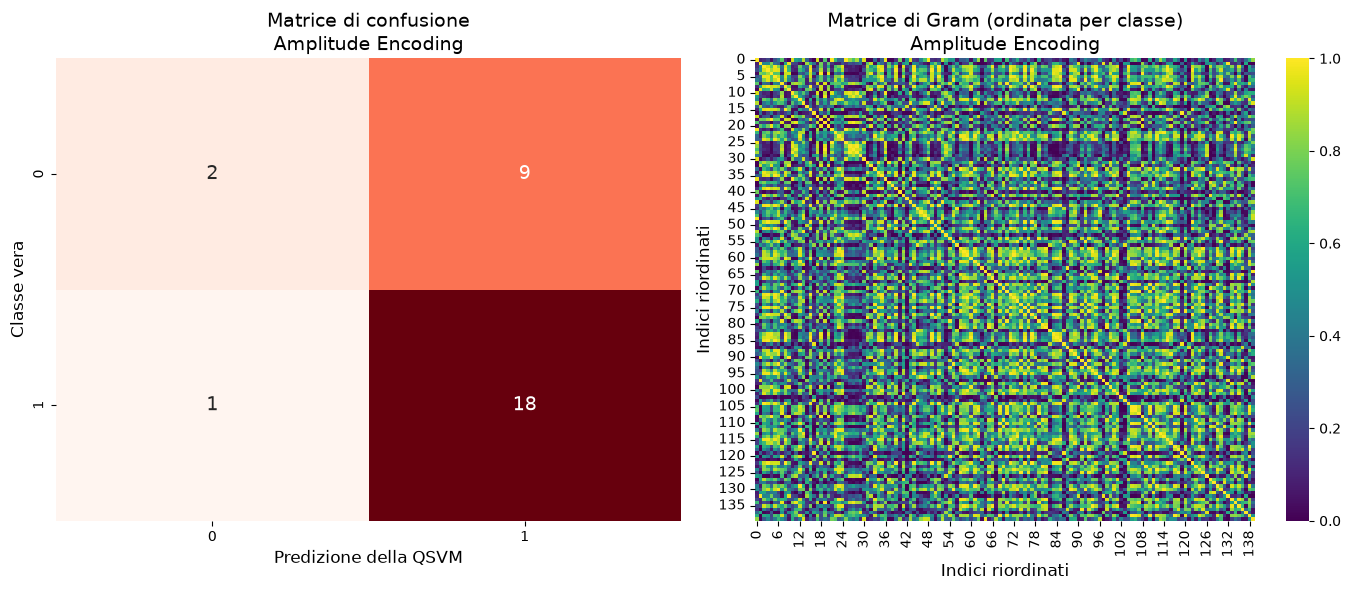

In [6]:
modello_amplitude, set_adattato_amplitude = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_amplitude,
    iperparametri_quantistici = iperparametri_quantistici_amplitude,
    iperparametri_classici = iperparametri_classici_amplitude
)

# Angle Encoding

## Iperparametri dell'encoding

In [7]:
# Iperparametri quantistici: None.

iperparametri_quantistici_angle = {}

# Iperparametri classici.

iperparametri_classici_angle = {"C": [1.0, 10.0, 100.0, 1000.0]} 

## QSVM

QUANTUM SUPPORT VECTOR MACHINE PER ANGLE ENCODING

Destinazione output: risultati_run/20260629/20260629_111736/angle_encoding_20260629_111736


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 4/4


Miglior iperparametro classico per C: 10.0
F1-Score (Macro) del miglior modello sul validation set: 96.47%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   100.00%   │  90.91%  │   95.24%   │              11               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   95.00%    │ 100.00%  │   97.44%   │              19               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   97.50%    │  95.45%  │   96.34%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


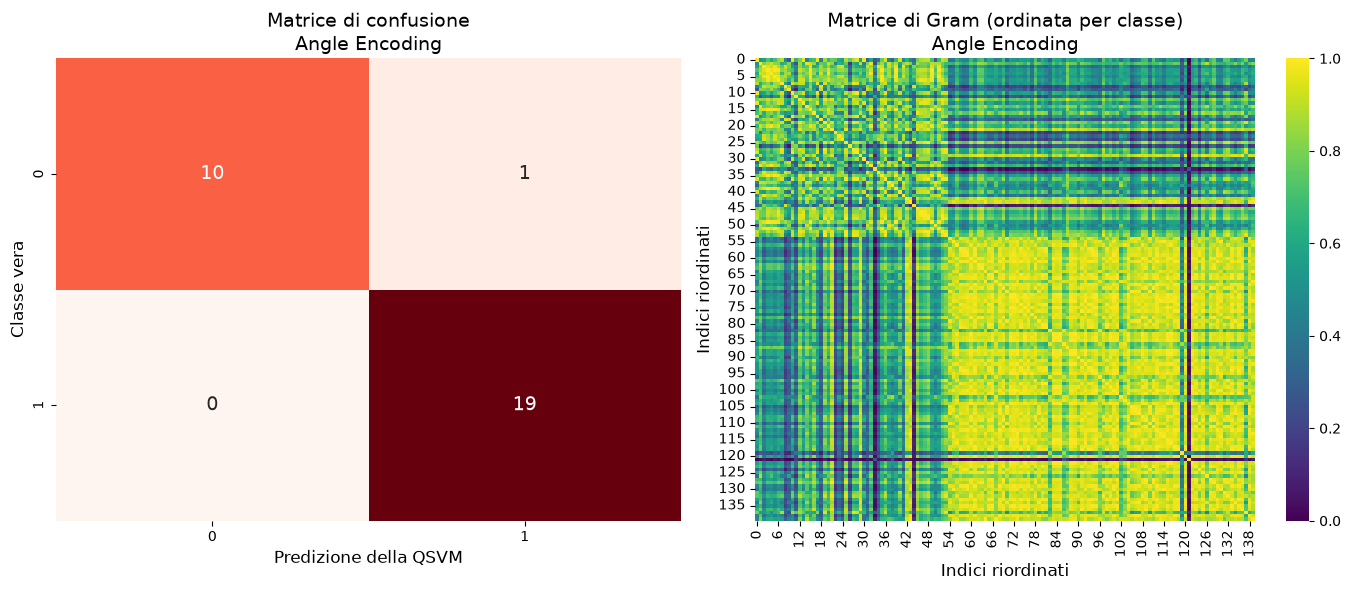

In [8]:
modello_angle, set_adattato_angle = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_angle,
    iperparametri_quantistici = iperparametri_quantistici_angle,
    iperparametri_classici = iperparametri_classici_angle
)

# Basis Encoding

## Iperparametri dell'encoding

In [9]:
# Iperparametri quantistici: "tau_bit_per_feature" (con che precisione discretizziamo le misure reali delle varie features dei campioni).

iperparametri_quantistici_basis = {"tau_bit_per_feature": [2, 3, 4, 5]} 

# Iperparametri classici.

iperparametri_classici_basis = {"C": [1.0, 10.0, 100.0, 1000.0]} 

## QSVM 

QUANTUM SUPPORT VECTOR MACHINE PER BASIS ENCODING

Destinazione output: risultati_run/20260629/20260629_111736/basis_encoding_20260629_111736


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 16/16


Miglior iperparametro quantistico per tau_bit_per_feature: 2
Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 84.13%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   75.00%    │  54.55%  │   63.16%   │              11               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   77.27%    │  89.47%  │   82.93%   │              19               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   76.14%    │  72.01%  │   73.04%   │              30               │
╘═══════════════╧═════════════╧══════════╧════════════╧═══════════════════════════════╛


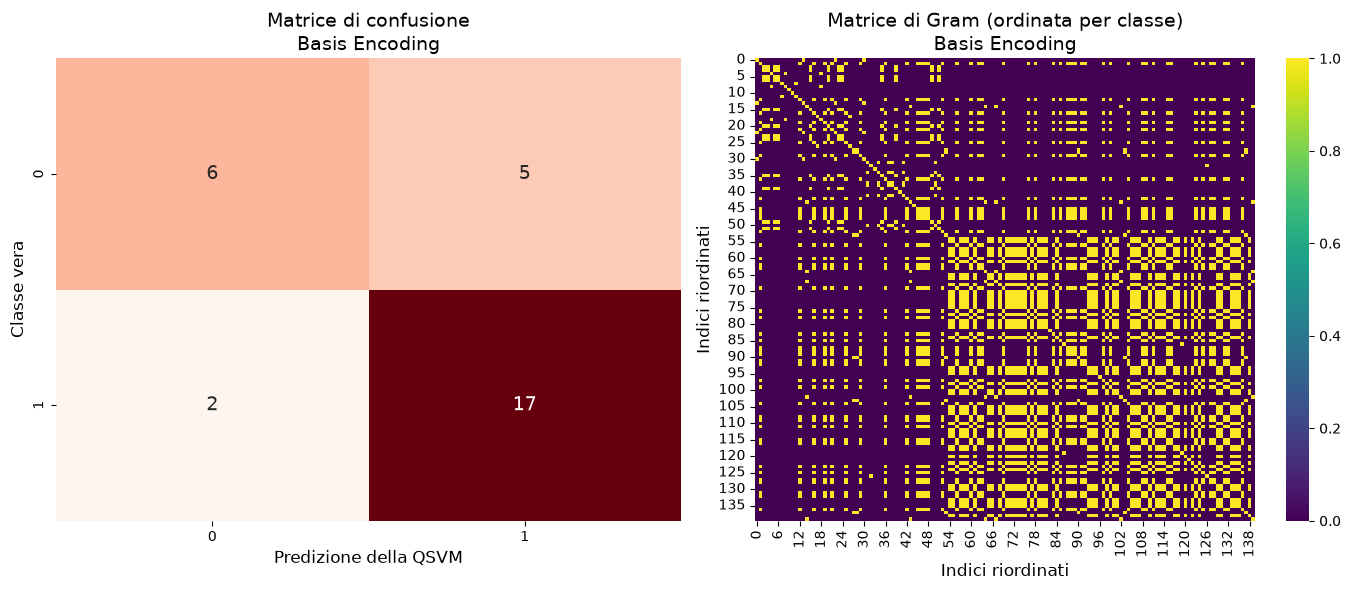

In [10]:
modello_basis, set_adattato_basis = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_basis,   
    iperparametri_quantistici = iperparametri_quantistici_basis,
    iperparametri_classici = iperparametri_classici_basis
)

# IQP Encoding

## Iperparametri dell'encoding

In [11]:
# Creazione dei pattern con cui entanglare le features nell'IQP Encoding, cioè dell'iperparametro "pattern". 

pattern_catena = [[i, i + 1] for i in range(numero_features - 1)] # Catena.
pattern_anello = [[i, i + 1] for i in range(numero_features - 1)] + [[numero_features - 1, 0]] # Anello (come catena, ma poi chiude alla fine).
pattern_tutti = [list(coppia) for coppia in itertools.combinations(range(numero_features), 2)] # Connessione totale (l'1 col 2 e col 3, il 2 col 3 e così via).

# Iperparametri quantistici: "numero_ripetizioni" (quante volte si ripete il circuito quantistico), "pattern" (come vengono entanglati i qubits).

iperparametri_quantistici_IQP = {"numero_ripetizioni": [1, 2, 3, 4], "pattern": [pattern_catena, pattern_anello, pattern_tutti]}

# Iperparametri classici.

iperparametri_classici_IQP = {"C": [1.0, 10.0, 100.0, 1000.0]}

## QSVM

QUANTUM SUPPORT VECTOR MACHINE PER IQP ENCODING

Destinazione output: risultati_run/20260629/20260629_111736/iqp_encoding_20260629_111736


Addestramento dei modelli e validazione sugli iperparametri: 100%|██████████| 48/48


Miglior iperparametro quantistico per numero_ripetizioni: 3
Miglior iperparametro quantistico per pattern: [[0, 1], [1, 2]]
Miglior iperparametro classico per C: 1.0
F1-Score (Macro) del miglior modello sul validation set: 96.47%


DIAGNOSI FINALE SUL TEST SET:

╒═══════════════╤═════════════╤══════════╤════════════╤═══════════════════════════════╕
│               │  Precision  │  Recall  │  F1-Score  │  Campioni realmente presenti  │
╞═══════════════╪═════════════╪══════════╪════════════╪═══════════════════════════════╡
│   Classe 0    │   100.00%   │  90.91%  │   95.24%   │              11               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│   Classe 1    │   95.00%    │ 100.00%  │   97.44%   │              19               │
├───────────────┼─────────────┼──────────┼────────────┼───────────────────────────────┤
│ Medie (Macro) │   97.50%    │  95.45%  │   96.34%   │              30               │
╘═══════════════╧═════════════╧══

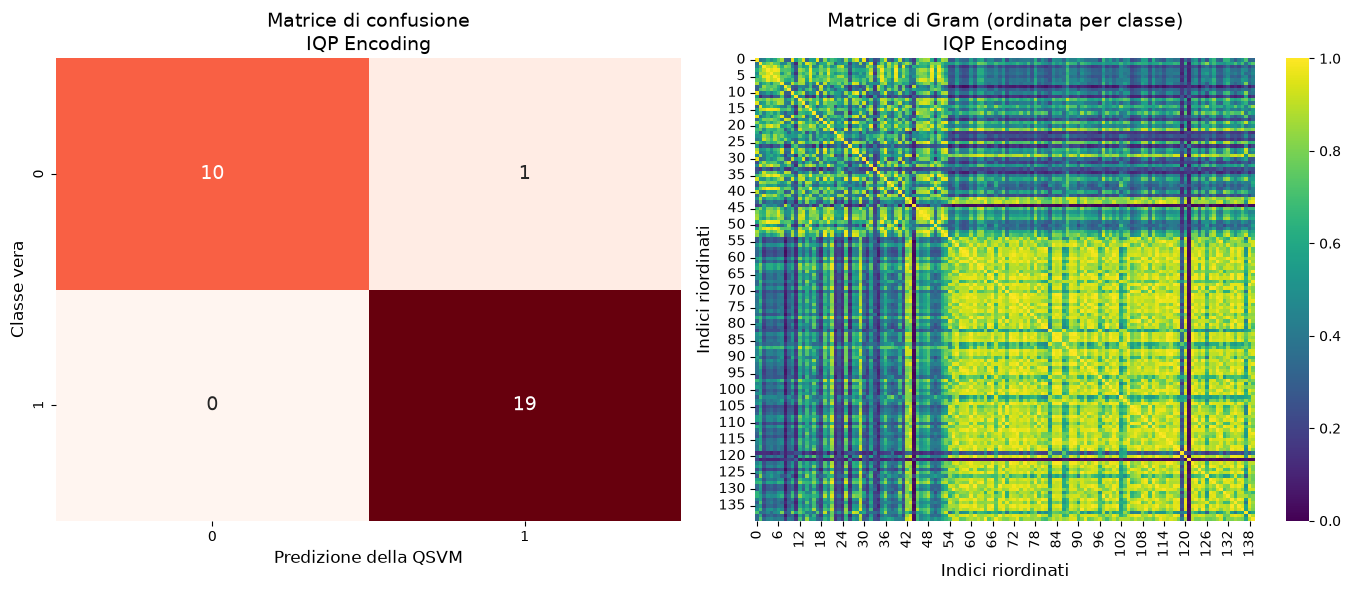

In [12]:
modello_IQP, set_adattato_IQP = costruisci_qsvm(
    set_preparato = set_preparato,
    numero_features = numero_features,
    modulo_encoding = kernel_IQP,
    iperparametri_quantistici = iperparametri_quantistici_IQP,
    iperparametri_classici = iperparametri_classici_IQP
)